In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import re, importlib
from tqdm import tqdm
import os, sys, json
from itertools import product
from web_model import params, model  # Load parameters and model implementation.
from pathlib import Path
import time
import PBcombos as pbc
from collections import Counter
print(os.getcwd())
importlib.reload(model)
importlib.reload(pbc)
pd.options.display.float_format = "{:20,.4f}".format
print(pd.__version__)
print(np.__version__)

root_path = Path().parent

param_list = list(params.df_typing_formatting.T.to_dict().values())
model_params = {row["keys"]: row["values"] for row in param_list}
sm = model.SolveModel(model_params)
prod_change_dict = sm.prod_change_dict

/home/gustav/dev/pbtech
2.2.2
1.26.4


In [ ]:
def check(discrete_vals = [0,1], param_idx_restrict_vals=None, file_name_extension=''):
    """ Method for assessing outcome of policy combinatins"""
    good_for_all_pbs = []
    pb_improvement_cnts = {}
    pb_improvement_cnt_details = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=1, param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension=file_name_extension)
    pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        assert not 2 in c
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
            for ii, pb in enumerate(pbs):
                pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
        else:
            pb_improvement_cnts[sum_pb_effects] = 1
            pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects, dict(sorted(pb_improvement_cnts.items())), dict(sorted(pb_improvement_cnt_details.items()))

## O, 1 percents runs

In [19]:

param_idx_restrict_vals = {4: 0, 7: 0, 12: 0, 14: 0, 16: 0}
good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check(discrete_vals = [0,1], param_idx_restrict_vals=param_idx_restrict_vals, file_name_extension="_restrict_4096")
#good_for_all_pbs_0_1, good_for_clim_biod_effects_0_1, pb_improvement_cnts_0_1, pb_improvement_cnt_details_0_1 = check()

  0%|          | 0/131072 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_restrict_4096.npy


  3%|▎         | 4096/131072 [00:00<00:02, 56800.65it/s]

0.07401013374328613


In [32]:
pb_improvement_cnts_0_1
good_for_all_pbs_0_1
pb_improvement_cnts_0_1

{0: 5, 1: 85, 2: 265, 3: 247, 4: 860, 5: 2184, 6: 449, 7: 1}

([<matplotlib.axis.YTick at 0x7f5822637620>,
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14'),
  Text(0, 16.0, '16'),
  Text(0, 18.0, '18'),
  Text(0, 20.0, '20'),
  Text(0, 22.0, '22')])

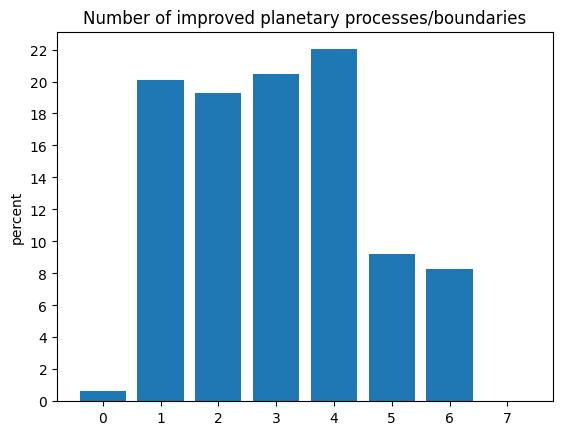

In [34]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots()
ax.set_ylabel("percent")
ax.set_title("Number of improved planetary processes/boundaries")

norm_pb_improvement_cnts_0_1 = {k: 100*v/sum(pb_improvement_cnts.values()) for k, v in pb_improvement_cnts.items()}
plt.bar(pb_improvement_cnts_0_1.keys(), norm_pb_improvement_cnts_0_1.values())
plt.yticks(np.arange(0, max(norm_pb_improvement_cnts_0_1.values()), 2))

## O, 1 and 2 percents

In [26]:
discrete_vals = [0,1,2]

discrete_vals_str = [str(d) for d in discrete_vals]
var_file = root_path / "results" / f"pb_combos_vars_{'_'.join(discrete_vals_str)}.txt"
with open(var_file, "r") as f:
    pbs = json.loads(f.read())

pbs

['Aerosol effect',
 'CO2 effect',
 'Biodiv. incl. climate effect',
 'Biogeochem. effect',
 'Freshwater effect',
 'Ocean acid. effect',
 'Land-use effect']

In [27]:
good_for_all_pbs = []
discrete_vals = [0,1,2]
pb_improvement_cnts = {}    # Out of all the combinations how many improve exactly 1,2,3,4,5,6 boundaries
pb_improvement_cnt_details = {}   # Out of all the combinations that improve exactly 1,2,3,4,5,6 boundaries which one is the most unlikely to improve 
good_for_clim_biod_effects = []
total =len(discrete_vals)**17
import time
st = time.time()
combo_results = pbc.check_combos(discrete_vals, root_path / "results")
pbs = ['Aerosol effect','CO2 effect','Biodiv. incl. climate effect','Biogeochem. effect','Freshwater effect','Ocean acid. effect','Land-use effect']

for c, pb_effects in tqdm(combo_results, total=total):
    sum_pb_effects = sum(pb_effects)
    if sum_pb_effects in pb_improvement_cnts:
        pb_improvement_cnts[sum_pb_effects] += 1 
        for ii, pb in enumerate(pbs):
            pb_improvement_cnt_details[sum_pb_effects][pb] += int(pb_effects[ii])
    else:
        pb_improvement_cnts[sum_pb_effects] = 1
        pb_improvement_cnt_details[sum_pb_effects] = dict(list(zip(pbs, [int(pe) for pe in pb_effects])))

    if pb_effects[1] and pb_effects[2]:
        good_for_clim_biod_effects.append(c)

    if all(pb_effects):
        good_for_all_pbs.append(c)
print(time.time()-st)


  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221963.72it/s]


loading: pb_1_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:47, 220319.86it/s]


...

loading: pb_9_combos_0_1_2.npy


 10%|▉         | 12914016/129140163 [00:58<08:43, 221821.11it/s]]


loading: pb_10_combos_0_1_2.npy


100%|██████████| 129140163/129140163 [09:55<00:00, 217007.61it/s]

595.0968403816223


In [30]:
pb_improvement_cnts

{0: 791795,
 3: 25990715,
 4: 24934512,
 2: 26428897,
 5: 28432686,
 1: 11883940,
 6: 10677580,
 7: 38}

In [36]:
print(pb_improvement_cnts[6])
pb_improvement_cnt_details[6]

10677580


{'Aerosol effect': 10677580,
 'CO2 effect': 10677580,
 'Biodiv. incl. climate effect': 140,
 'Biogeochem. effect': 10677580,
 'Freshwater effect': 10677501,
 'Ocean acid. effect': 10677580,
 'Land-use effect': 10677519}

In [25]:
tcb=4096 #2**17
pb_improvement_cnts = pb_improvement_cnts_0_1
pb_improvement_cnt_details = pb_improvement_cnt_details_0_1
pb_improvement_cnts = dict(sorted(pb_improvement_cnts.items()))
for ii, (pbsolved, pbcnt) in enumerate(pb_improvement_cnts.items()):
    #print(ii, round(100*pbcnt/tcb, 3), pb_improvement_cnt_details[ii])
    climate_improv = round(100*pb_improvement_cnt_details[ii]['CO2 effect']/pbcnt, 2)
    biodiv_improv = round(100*pb_improvement_cnt_details[ii]['Biodiv. incl. climate effect']/pbcnt, 5)
    print(f"{round(pbcnt*100/tcb,1)}%")
    #print(f"({climate_improv}% / {biodiv_improv}%)")
    #print('---')

0.1%
2.1%
6.5%
6.0%
21.0%
53.3%
11.0%
0.0%


In [15]:


tech_changes = list(prod_change_dict.keys())
df = pd.DataFrame(index=tech_changes, columns=["0%", "1%", "2%"])
good_combos = {k: [] for k in tech_changes}
cnt= 0
for gc in good_for_all_pbs:
    for ii, k in enumerate(tech_changes):
        good_combos[k].append(gc[ii])


for k in tech_changes:
    good_combos[k] = dict(Counter(good_combos[k]))
    df.loc[k, "0%"] = good_combos[k].get(0, 0)
    df.loc[k, "1%"] = good_combos[k].get(1, 0)
    df.loc[k, "2%"] = good_combos[k].get(2, 0)

print('cnt',cnt)
good_combos

df.to_csv(root_path / "results" / 'good_for_all_pbs.csv')

cnt 0


In [23]:
sum_good_for_clim_biod_effects
total=sum(pb_improvement_cnts.values())
pb_improvement_list = sorted(pb_improvement_cnts.items(), key=lambda x: x[0])
pb_improvement_list = [(pbi[0], round(100*pbi[1]/total,6)) for pbi in pb_improvement_list]
for pbi in pb_improvement_list:
    print(pbi[0], str(pbi[1]) + "%")

0 0.613128%
1 9.202358%
2 20.465281%
3 20.125974%
4 19.3081%
5 22.01692%
6 8.26821%
7 2.9e-05%


## -1, O,  and 1 percents

In [20]:
def check(discrete_vals, batches=1):

    good_for_all_pbs = []
    pb_improvement_cnts = {}
    good_for_clim_biod_effects = []
    total =len(discrete_vals)**17
    import time
    st = time.time()
    combo_results = pbc.check_combos(discrete_vals, root_path / "results", batches=batches)
    for c, pb_effects in tqdm(combo_results, total=total):
        sum_pb_effects = sum(pb_effects)
        if sum_pb_effects in pb_improvement_cnts:
            pb_improvement_cnts[sum_pb_effects] += 1 
        else:
            pb_improvement_cnts[sum_pb_effects] = 1

        if pb_effects[1] and pb_effects[2]:
            good_for_clim_biod_effects.append(c)

        if all(pb_effects):
            good_for_all_pbs.append(c)
    print(time.time()-st)
    return good_for_all_pbs, good_for_clim_biod_effects

discrete_vals = [-1,0,1]
good_for_all_pbs__1_0_1, good_for_clim_biod_effects__1_0_1 = check(discrete_vals, batches=10)

  0%|          | 0/129140163 [00:00<?, ?it/s]

loading: pb_0_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:15, 368684.12it/s]


loading: pb_1_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:34<05:14, 369049.51it/s]


...

loading: pb_9_combos_-1_0_1.npy


 10%|▉         | 12914016/129140163 [00:35<05:16, 367562.17it/s]]


loading: pb_10_combos_-1_0_1.npy


100%|██████████| 129140163/129140163 [06:12<00:00, 347002.90it/s]

372.1601872444153


In [27]:
print(len(good_for_all_pbs__1_0_1)/129140163) 
print(len(good_for_clim_biod_effects__1_0_1)/129140163) 

0.03762235455750509
0.32296540465106893


## Check specific combo

In [72]:
def pb_boundary(c, pack=True):
    dfnp = np.array([[0.0010672170921913766, 0.041064083724359594, 0.03606265998995495, -0.09056933011478599, -0.04212802843617142, 0.041064083724359594, -0.009457889673203462, 1.0, 0.0], [0.000280677776028135, 0.008976494788867724, 0.01177139088129886, 0.03526377679207529, 0.01852054800088953, 0.008976494788867724, 0.02102473117337316, 1.0, 0.0], [0.00020340503955239205, 0.006589680358849447, -0.006776759136928323, -0.7402134722784179, 0.022800158842504303, 0.006589680358849447, 0.026026952518861418, 1.0, 0.0], [9.9185328694472e-05, 0.003172095057746263, 0.00415974962560961, 0.012461440095563102, -0.3842849415925758, 0.003172095057746263, 0.0074296757714614955, 1.0, 0.0], [0.003884525919690355, 0.12423294486923242, 0.1629137640898226, 0.48804382346702246, 0.2563207881093982, 0.12423294486923242, 0.290978196967412, 1.0, 0.0], [-0.00024021385317936803, -0.007525790597789012, 0.0038170542693505283, -0.7438123683284646, 0.0015344277486948853, -0.007525790597789012, 0.0020087592144643757, 1.0, -1.0], [0.00014337353262626137, 0.004561989962317463, 0.015669995737233045, -0.47658456002351374, 0.006872888059443555, 0.004561989962317463, 0.007762458447490711, 1.0, 0.0], [0.0003002453601054886, 0.009553480994320743, 0.03281528624420327, 0.48018345607356033, 0.014392843034365638, 0.009553480994320743, 0.01625573485690654, 1.0, 0.0], [-0.0006111707649527577, -0.01246899195121234, -0.002054702421672161, 0.025601994295128286, 0.009820830412398384, -0.01246899195121234, -0.0347027538961542, -1.0, -1.0], [-0.010601937582399506, -0.18222918227136342, 0.006492022805304476, 0.030006844126706043, -0.01827941758527299, -0.18222918227136342, 0.02399593109999751, 0.0, -1.0], [-0.001378795905645309, -0.02429506543859241, 0.001620392870027576, 0.006529822849102153, -0.0011754369121571736, -0.02429506543859241, 0.0016281928468621894, 0.0, -1.0], [-0.011353948105761754, -0.19686385686103025, 0.005973005270065723, 0.05761786114221153, -0.007917923440818157, -0.19686385686103025, -0.011396641580090863, 0.0, -1.0], [0.007955944854472449, 0.2614958180324138, 0.10111898011515574, 0.28702815750204236, 0.16405574909673404, 0.2614958180324138, -0.6538286204894805, 1.0, 0.0], [-4.432538898446151e-05, -0.001712370567540188, 0.007170572698467215, -0.0027423063067561065, -0.0014945870566598976, -0.001712370567540188, 0.0026320395286490873, 0.0, -1.0], [0.00019221806859163147, 0.0017392470741345537, 0.04032729896277232, -0.018034945822891793, -0.00826967604066459, 0.0017392470741345537, 0.014594754586366124, 1.0, -1.0], [1.0008546572808551e-05, -0.0008635002555022078, 0.059912845007070725, -0.0014463897522506383, -0.0005926498932396549, -0.0008635002555022078, 0.013885795678424254, 1.0, 0.0], [0.00013047951009683057, 0.0035842060759157883, 0.15737326705952404, -0.001374217876452746, -0.00039992010625888993, 0.0035842060759157883, -0.01968233909427637, 1.0, -1.0]])
    dc = dfnp * np.array(c).reshape(len(c), 1)
    dc_sum = dc.sum(axis=0)[0:7]<=0
    return dc_sum

In [92]:
tech_params = {
        ("A_LA", "Land use efficiency in agriculture"): 0,
        ("A_EpsA", "Energy efficiency agriculture"): 1,
        ("A_P", "Fertilizer efficiency in agriculture"): 1,
        ("A_W", "Water efficiency in agriculture"): 1,
        ("A_MA", "Other inputs efficiency in agriculture"): 0,
        ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
        ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
        ("P_MP", "Other inputs efficiency in fertilizer prod."): 0,
        ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
        ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
        ("Eps_R", "Renewable efficiency in energy service prod."): 1,
        ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
        ("Y_MY", "Other inputs efficiency in manufacturing"): 0,
        ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
        ("Fi_MFi", "Other inputs efficiency in fisheries"): 0,
        ("T_LT", "Land use efficiency in timber prod."): 1,
        ("T_MT", "Other inputs efficiency in timber prod."): 0,
    }
#tech_params = {k: int(v==0) for k,v in tech_params.items()}
results=pb_boundary(list(tech_params.values()), pack=False)
pbs = {'Aerosol effect': None,
 'CO2 effect': None,
 'Biodiv. incl. climate effect': None,
 'Biogeochem. effect': None,
 'Freshwater effect': None,
 'Ocean acid. effect': None,
 'Land-use effect': None
 }
{pb: results[ii] for ii, (pb, _) in enumerate(pbs.items())}

{'Aerosol effect': True,
 'CO2 effect': True,
 'Biodiv. incl. climate effect': False,
 'Biogeochem. effect': True,
 'Freshwater effect': True,
 'Ocean acid. effect': True,
 'Land-use effect': False}

# Latte

In [26]:
for v in pbc.compute_pb_tech_individual()[0]*1e12:
    print(round(v))

                                          description  max value  min value  \
0             $L_A$ $\text{(land-share agriculture)}$   0.007377   0.007377   
1                  $L_T$ $\text{(land-share timber)}$   0.017301   0.017301   
2                   $L_U$ $\text{(land-share other)}$  -0.009458  -0.009458   
3                $E$ $\text{(fossil-fuel extracted)}$   0.023858   0.023858   
4   $E_{\mathcal{E}}$ $\text{(fossil-fuel use ener...   0.025302   0.025302   
5   $E_P$ $\text{(fossil-fuel use fertilizer prod.)}$  -0.050352  -0.050352   
6          $E_F$ $\text{(fossil-fuel use fisheries)}$  -0.071053  -0.071053   
7     $A\;\;$ $\text{(agriculture total production)}$   0.163028   0.163028   
8     $A_B$ $\text{(agriculture prod. for biofuels)}$   0.443671   0.443671   
9         $A_F$ $\text{(agriculture prod. for food)}$   0.151942   0.151942   
10       $\mathcal{E}\;\;$ $\text{(energy services)}$   0.027679   0.027679   
11  $\mathcal{E}_A$ $\text{(energy for agriculture)}

In [7]:
# Generate result and feasible param space for a specific combination of tech params and boundaries

import warnings, importlib
warnings.simplefilter(action='ignore', category=FutureWarning)
import PBcombos as pbc
importlib.reload(pbc)

tech_params = {
    ("A_LA", "Land use efficiency in agriculture"): 1,
    ("A_EpsA", "Energy efficiency agriculture"): 1,
    ("A_P", "Fertilizer efficiency in agriculture"): 1,
    ("A_W", "Water efficiency in agriculture"): 1,
    ("A_MA", "Other inputs efficiency in agriculture"): 1,
    ("P_EP", "Fossil fuel efficiency in fertilizer prod."): 1,
    ("P_Pho", "Phosphor efficiency in fertilizer prod."): 1,
    ("P_MP", "Other inputs efficiency in fertilizer prod."): 1,
    ("Eps_AB", "Biofuel efficiency in energy service prod."): 1,
    ("Eps_EEps", "Fossil fuel efficiency in energy service prod."): 1,
    ("Eps_R", "Renewable efficiency in energy service prod."): 1,
    ("Y_EpsY", "Energy services efficiency in manufacturing"): 1,
    ("Y_MY", "Other inputs efficiency in manufacturing"): 1,
    ("Fi_EFi", "Fossil fuels efficiency in fisheries"): 1,
    ("Fi_MFi", "Other inputs efficiency in fisheries"): 1,
    ("T_LT", "Land use efficiency in timber prod."): 1,
    ("T_MT", "Other inputs efficiency in timber prod."): 1,
}
boundaries = {'Aerosol effect': 1,
 'CO2 effect': 1,
 'Biodiv. incl. climate effect': 1,
 'Biogeochem. effect': 1,
 'Freshwater effect': 1,
 'Ocean acid. effect': 1,
 'Land-use effect': 1
}

result, tech_param_range = pbc.gen_latte(tech_params, boundaries, constraints=[0,1], compute_vertices=False)
# 7.506175251765734e-20
1.426820636564419e-19
result

Running latte
Compute polyhedra
['Ray Support Algorithm.', 'The codimension is 28', '', '  Left =  10,  Col =  22,  Size =       18  Time:  0.00', '  Left =  10,  Col =  22,  Size =       18,   Index = 0/7', '  Left =  10,  Col =  22,  Size =       84,  Time:  0.00                ', '', '  Left =   9,  Col =  23,  Size =       84  Time:  0.00', '  Left =   9,  Col =  23,  Size =       32,   Index = 0/21', '  Left =   9,  Col =  23,  Size =      234,  Time:  0.00                ', '', '  Left =   8,  Col =  27,  Size =      234  Time:  0.00', '  Left =   8,  Col =  27,  Size =       59,   Index = 0/54', '  Left =   8,  Col =  27,  Size =      354,  Time:  0.00                ', '', '  Left =   7,  Col =  26,  Size =      354  Time:  0.00', '  Left =   7,  Col =  26,  Size =       99,   Index = 0/92', '  Left =   7,  Col =  26,  Size =      716,  Time:  0.01                ', '', '  Left =   6,  Col =  25,  Size =      716  Time:  0.01', '  Left =   6,  Col =  25,  Size =      120,   Ind

In [4]:
result/100000000**17

5.656068959575076e-20

In [6]:
result

In [42]:
from itertools import product
coords = list(product(range(7), repeat=2))
results = np.empty((7,7))
for c in coords:
    if c[0]==c[1]:
        continue
    active_boundaries = np.zeros(7)
    active_boundaries[c[0]] = 1
    active_boundaries[c[1]] = 1
    print(c, active_boundaries)
    b = dict(zip(list(boundaries.keys()), active_boundaries))
    result, _ = pbc.gen_latte(tech_params, b, constraints=[0,1])
    results[c] = result
    
#for boundaries
#    result, tech_param_range = pbc.gen_latte(tech_params, boundaries, constraints=[0,1])

(0, 1) [1. 1. 0. 0. 0. 0. 0.]
(0, 2) [1. 0. 1. 0. 0. 0. 0.]
(0, 3) [1. 0. 0. 1. 0. 0. 0.]
(0, 4) [1. 0. 0. 0. 1. 0. 0.]
(0, 5) [1. 0. 0. 0. 0. 1. 0.]
(0, 6) [1. 0. 0. 0. 0. 0. 1.]
(1, 0) [1. 1. 0. 0. 0. 0. 0.]
(1, 2) [0. 1. 1. 0. 0. 0. 0.]
(1, 3) [0. 1. 0. 1. 0. 0. 0.]
(1, 4) [0. 1. 0. 0. 1. 0. 0.]
(1, 5) [0. 1. 0. 0. 0. 1. 0.]
(1, 6) [0. 1. 0. 0. 0. 0. 1.]
(2, 0) [1. 0. 1. 0. 0. 0. 0.]
(2, 1) [0. 1. 1. 0. 0. 0. 0.]
(2, 3) [0. 0. 1. 1. 0. 0. 0.]
(2, 4) [0. 0. 1. 0. 1. 0. 0.]
(2, 5) [0. 0. 1. 0. 0. 1. 0.]
(2, 6) [0. 0. 1. 0. 0. 0. 1.]
(3, 0) [1. 0. 0. 1. 0. 0. 0.]
(3, 1) [0. 1. 0. 1. 0. 0. 0.]
(3, 2) [0. 0. 1. 1. 0. 0. 0.]
(3, 4) [0. 0. 0. 1. 1. 0. 0.]
(3, 5) [0. 0. 0. 1. 0. 1. 0.]
(3, 6) [0. 0. 0. 1. 0. 0. 1.]
(4, 0) [1. 0. 0. 0. 1. 0. 0.]
(4, 1) [0. 1. 0. 0. 1. 0. 0.]
(4, 2) [0. 0. 1. 0. 1. 0. 0.]
(4, 3) [0. 0. 0. 1. 1. 0. 0.]
(4, 5) [0. 0. 0. 0. 1. 1. 0.]
(4, 6) [0. 0. 0. 0. 1. 0. 1.]
(5, 0) [1. 0. 0. 0. 0. 1. 0.]
(5, 1) [0. 1. 0. 0. 0. 1. 0.]
(5, 2) [0. 0. 1. 0. 0. 1. 0.]
(5, 3) [0.

In [5]:
tech_param_range = {('A_LA', 'Land use efficiency in agriculture'): [0.2347951156432666, 0],
 ('A_EpsA', 'Energy efficiency agriculture'): [0.6319727089993222, 0],
 ('A_P', 'Fertilizer efficiency in agriculture'): [1, 0],
 ('A_W', 'Water efficiency in agriculture'): [1, 0],
 ('A_MA', 'Other inputs efficiency in agriculture'): [0.04566340864646694, 0],
 ('P_EP', 'Fossil fuel efficiency in fertilizer prod.'): [1, 0],
 ('P_Pho', 'Phosphor efficiency in fertilizer prod.'): [0.5384997157536912, 0],
 ('P_MP', 'Other inputs efficiency in fertilizer prod.'): [0.25714504476637556,
  0],
 ('Eps_AB', 'Biofuel efficiency in energy service prod.'): [1, 0],
 ('Eps_EEps',
  'Fossil fuel efficiency in energy service prod.'): [0.9718551674161944, 0],
 ('Eps_R', 'Renewable efficiency in energy service prod.'): [1, 0],
 ('Y_EpsY', 'Energy services efficiency in manufacturing'): [1, 0],
 ('Y_MY', 'Other inputs efficiency in manufacturing'): [0.07806629925333382,
  0],
 ('Fi_EFi', 'Fossil fuels efficiency in fisheries'): [1, 0],
 ('Fi_MFi', 'Other inputs efficiency in fisheries'): [0.21070621307424173, 0],
 ('T_LT', 'Land use efficiency in timber prod.'): [0.14152655783303345, 0],
 ('T_MT', 'Other inputs efficiency in timber prod.'): [0.053875630750604545,
  0]}

In [8]:
df = pd.DataFrame.from_dict({k[1]: v[0]*1 for k, v in tech_param_range.items()}, orient='index')
df.columns = ["space"]
df

TypeError: 'NoneType' object is not subscriptable

-0.2 0 1.0
0.8 0 1.0
1.8 0 0.5384997157536912
2.8 0 0.14152655783303345
3.8 0 0.2347951156432666
4.8 0 1.0
5.8 0 1.0
6.8 0 0.8627951575808473
7.8 0 1.0
8.8 0 1.0
9.8 0 0.6066568025098343
10.8 0 1.0
0.009366196207174608


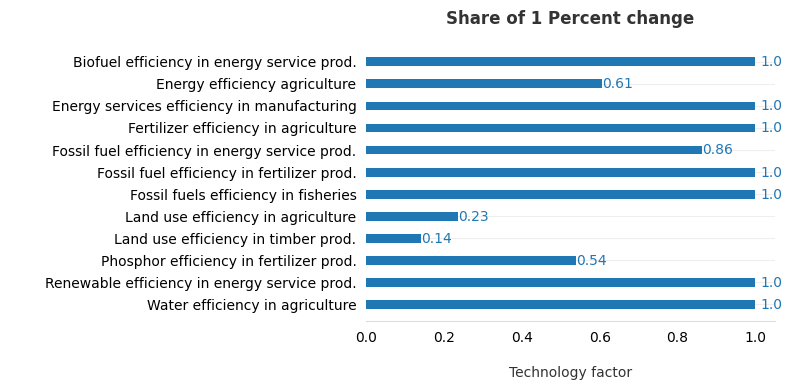

In [15]:
# Use Matplotlib's font manager to rebuild the font library.
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager
plt.rcdefaults()
# Use the newly integrated Roboto font family for all text.
plt.rc('font', family='sans-serif')
plt.rcParams['figure.figsize'] = (8, 4)
fig, ax = plt.subplots()

df = pd.DataFrame.from_dict({k[1]: v[0] for k, v in tech_param_range.items() if v}, orient='index').sort_index(ascending=False)
df.columns = ["space"]

# Save the chart so we can loop through the bars below.
bars = ax.barh(
    df.index,
    df['space'], 
    height = 0.4,
    align = 'center',
)

# Axis formatting.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(bottom=False, left=False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

# Add text annotations to the top of the bars.
bar_color = bars[0].get_facecolor()
vol= 1
for bar in bars:
  vol = vol* bar.get_width()
  print(bar.get_y(),bar.get_x(), bar.get_width())
  ax.text(
      bar.get_width() + 0.04,
      bar.get_y(),
      round(bar.get_width(), 2),
      horizontalalignment='center',
      color=bar_color,
      weight='normal'
  )

# Add labels and a title.
ax.set_xlabel('Technology factor', labelpad=15, color='#333333', )
ax.set_ylabel(' ', labelpad=15, color='#333333')
ax.set_title('Share of 1 Percent change', pad=15, color='#333333',
             weight='bold')
print(vol)
fig.tight_layout()

In [16]:
float(result)/vol

2.756164269710899e-07